# Lab 3 — KNN

---

## Background

The **CDC/ATSDR Environmental Justice Index (EJI)** measures the cumulative environmental and social burdens faced by communities across the United States at the census-tract level. It combines three modules:

- **Environmental Burden Module (EBM)**: air quality, proximity to hazardous waste sites, impaired water bodies
- **Social Vulnerability Module (SVM)**: poverty, race/ethnicity, housing conditions, health insurance
- **Health Vulnerability Module (HVM)**: prevalence of asthma, cancer, diabetes, mental illness

Our response variable of interest, **`E_TOTCR`**, is the EPA-modeled **lifetime cancer risk from inhalation of air toxics** — the estimated probability that a resident exposed continuously over a lifetime will develop cancer from airborne chemicals alone.

---

### Download the Data

Follow these instructions to obtain the data for this lab:

1. Navigate to [this link](https://www.atsdr.cdc.gov/place-health/php/eji/eji-data-download.html)
2. Select the 2024 dropdown for the United States.
3. **Choose the CSV File Type, and then click "Go"**.
4. Add your data to the `gitignore`

---

### The Dataset

Each row is a **U.S. census tract**. The key columns used in this lab are:

| Column | Description | 
|---|---|
| `E_TOTCR` | Lifetime cancer risk from air toxics (EPA modeled) | 
| `EPL_TOTCR` | National percentile rank of `E_TOTCR` |
| `E_DSLPM` | Ambient diesel particulate matter (μg/m³) | 
| `E_PM` | Annual mean days above PM2.5 standard | 0 – 10 |
| `E_NPL` | % of tract within 1-mile of an EPA Superfund site | 
| `E_TRI` | % within 1-mile of a Toxic Release Inventory facility | 
| `E_TSD` | % within 1-mile of a hazardous waste TSD facility | 
| `E_RMP` | % within 1-mile of an RMP chemical accident site | 
| `E_POV200` | % of persons below 200% of the federal poverty level | 
| `E_MINRTY` | % identifying as a racial/ethnic minority | 



## Setup: Load Libraries and Read in Data

Run the cell below to load the EJI data, replace the EPA missing-value (`-999`) with `NaN`, and take a reproducible random sample of **10,000 tracts** so that cross-validated KNN runs in a reasonable time.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_score, recall_score, f1_score
)

# Load and clean
df_raw = pd.read_csv('data/EJI_2024_United_States_CSV/EJI_2024_United_States.csv')
df_raw = df_raw.replace(-999, np.nan)

# Reproducible 10,000-tract sample
df = df_raw.sample(n=10_000, random_state=42).reset_index(drop=True)
df.head(3)

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,...,E_AIAN,NHPI,E_NHPI,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag
0,72,21,31023,140000US72021031023,72021031023,72021031023,Bayamón Municipio,Puerto Rico,PR,Census Tract 310.23; Bayamón Municipio; Puerto...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-999,NaN
1,51,810,46400,140000US51810046400,51810046400,51810046400,Virginia Beach city,Virginia,VA,Census Tract 464; Virginia Beach city; Virginia,...,0.2,0.0,0.0,125.0,2.2,0.0,0.0,0.000000,-999,NaN
2,30,47,940600,140000US30047940600,30047940600,30047940600,Lake County,Montana,MT,Census Tract 9406; Lake County; Montana,...,26.6,6.0,0.1,420.0,8.6,3.0,0.1,99.994102,Flathead Reservation,1.0


## Step 1: Create the Target Variable and Explore the Data

We classify each census tract into one of three cancer risk categories based on its **national percentile rank** for air toxics cancer risk (`EPL_TOTCR`):

| Class | Label | `EPL_TOTCR` range |
|---|---|---|
| 0 | Low | < 0.33 |
| 1 | Medium | 0.33 – 0.67 |
| 2 | High | ≥ 0.67 |

1. Create a column called `risk_class` that assigns each row the appropriate class label.
2. Plot a bar chart showing the count of tracts in each class to visualize any potential class imbalance.

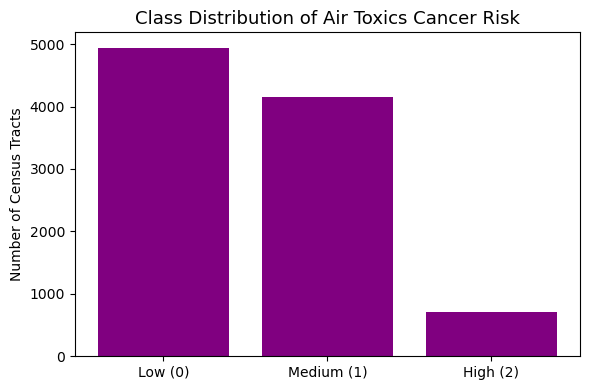


Class counts:
 risk_class
Low       4942
Medium    4148
High       702
Name: count, dtype: int64


In [5]:
# create classification function
def make_risk_class(epl):
    if pd.isna(epl):
        return np.nan
    elif epl < 0.33:
        return 0
    elif epl <0.67:
        return 1
    else:
        return 2

# apply function to df   
df['risk_class'] = df['EPL_TOTCR'].apply(make_risk_class) # don't need to add () to function bc apply expects it

# count tracts per class and sort 
counts = df['risk_class'].value_counts().sort_index() # putting it in order
labels = ['Low (0)', 'Medium (1)', 'High (2)']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts.values, color="purple")
ax.set_title('Class Distribution of Air Toxics Cancer Risk', fontsize=13)
ax.set_ylabel('Number of Census Tracts')
plt.tight_layout()
plt.show()
print('\nClass counts:\n', counts.rename({0: 'Low', 1: 'Medium', 2: 'High'}))

Class imbalance! won't predict high as often --> need to balance

## Why Scaling Matters for KNN

KNN classifies a new point by finding its *k* nearest training neighbors in feature space, often using Euclidean distance.

If one feature spans 0–100 while another spans 0–1, the large-range feature will dominate the distance calculation — even if the small-range feature is highly predictive. Standardizing each feature levels the playing field.

Let's take a look at the range of our observations for our 8 different features.

In [6]:
FEATURES = ['E_DSLPM', 'E_PM', 'E_NPL', 'E_TRI', 'E_TSD', 'E_RMP', 'E_POV200', 'E_MINRTY']

for f in FEATURES:
    low = df[f].min()
    high = df[f].max()
    range = high - low
    print(f"{f} min: {low:.4f} max: {high:.4f} range: {range:.4f}")


E_DSLPM min: 0.0069 max: 1.7343 range: 1.7274
E_PM min: 0.0000 max: 9.5750 range: 9.5750
E_NPL min: 0.0000 max: 100.0000 range: 100.0000
E_TRI min: 0.0000 max: 100.0000 range: 100.0000
E_TSD min: 0.0000 max: 100.0000 range: 100.0000
E_RMP min: 0.0000 max: 100.0000 range: 100.0000
E_POV200 min: 0.0000 max: 100.0000 range: 100.0000
E_MINRTY min: 0.0000 max: 100.0000 range: 100.0000


## Step 2: Prepare Features and Apply Scaling

Complete the following steps:

1. Build `df_model` from the columns `'E_NPL', 'E_TRI', 'E_TSD', 'E_RMP', 'E_DSLPM', 'E_PM', 'E_POV200', 'E_MINRTY'` plus `risk_class`. Drop any rows with NAs.
2. Separate predictors (`X`) from the response (`y`).
3. Split into 70% train / 30% test using `train_test_split` with `stratify=y` and `random_state=42`. Store as `X_train`, `X_test`, `y_train`, `y_test`.
4. Fit a `StandardScaler` on the **training set only** and transform both sets → `X_train_s`, `X_test_s`.

In [9]:
var_of_interest = ['E_NPL', 'E_TRI', 'E_TSD', 'E_RMP', 'E_DSLPM', 'E_PM', 'E_POV200', 'E_MINRTY', 'risk_class']
df_model = df[var_of_interest].dropna()

# Separate predictors (x) from response (y)
X = df_model[['E_NPL', 'E_TRI', 'E_TSD', 'E_RMP', 'E_DSLPM', 'E_PM', 'E_POV200', 'E_MINRTY']]
y = df_model['risk_class'].astype('int')

# 70/30 train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state= 42)

# fit the scaler ONLY to X test (don't scale testing data)
scaler = StandardScaler().fit(X_train)

# create scaled versions of training data
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)


print(f'Training set : {X_train_s.shape[0]:,} tracts')
print(f'Test set     : {X_test_s.shape[0]:,} tracts')

Training set : 6,815 tracts
Test set     : 2,921 tracts


## Scaled vs. Unscaled KNN

The cell below fits the *same* KNN model (k = 5) twice — once on raw features, once on scaled features — and prints both test accuracies. Do you see an accuracy boost from scaling?

In [10]:
# KNN on UNSCALED features
knn_raw = KNeighborsClassifier(n_neighbors= 5) # specify number of neighbors

# fit on training data
knn_raw.fit(X_train, y_train)

# predict using test data
y_pred = knn_raw.predict(X_test)

# compare predicition to y test (accuracy score)
acc_raw = accuracy_score(y_test, y_pred)

# KNN on SCALED features
knn_scaled = KNeighborsClassifier(n_neighbors= 5) # specify number of neighbors

# fit on training data
knn_scaled.fit(X_train_s, y_train)

# predict using test data
y_pred = knn_scaled.predict(X_test_s)

# compare predicition to y test (accuracy score)
acc_scaled = accuracy_score(y_test, y_pred)



print(f'Test accuracy — unscaled features : {acc_raw:.4f}')
print(f'Test accuracy — scaled features   : {acc_scaled:.4f}')
print(f'Accuracy gain from scaling        : +{acc_scaled - acc_raw:.4f}')

Test accuracy — unscaled features : 0.5430
Test accuracy — scaled features   : 0.6340
Accuracy gain from scaling        : +0.0911


Increased accuracy by 9% by scaling data!

## Step 3: Fit a K-Nearest Neighbors Classifier (k = 3)

A reminder on the `sklearn` workflow:

```python
model = SomeClassifier(hyperparameters)   # 1. Initialize
model.fit(X_train, y_train)               # 2. Train
y_pred = model.predict(X_test)            # 3. Predict
```

Using **scaled** training and test data:

1. Initialize a `KNeighborsClassifier` with `n_neighbors=3` and store it in `knn3`.
2. Fit on `X_train_s` / `y_train`.
3. Predict on `X_test_s`. Store your results in  `y_pred_knn3`.
4. Compute test accuracy. Store your results in `knn3_accuracy` using `accuracy_score`.

In [12]:
# step 1: initialize knn (nothing is learned yet!)
knn_3 = KNeighborsClassifier(n_neighbors = 3)

# step 2:
knn_3.fit(X_train_s, y_train)

# step 3:
y_pred_km3 = knn_3.predict(X_test_s)

# step 4:
knn3_accuracy = accuracy_score(y_test, y_perd_km3)

print(f'KNN (k=3) test accuracy: {knn3_accuracy:.4f}')

KNN (k=3) test accuracy: 0.6039


## Step 4: Visualize the Confusion Matrix

A **confusion matrix** shows how predictions map to true labels. Each row is the *true* class; each column is the *predicted* class. The diagonal entries are correct predictions; off-diagonal entries are mistakes.

|  | Pred Low | Pred Med | Pred High |
|---|---|---|---|
| **True Low** | TP (Low) | FP → Med | FP → High |
| **True Med** | FN → Low | TP (Med) | FP → High |
| **True High** | FN → Low | FN → Med | TP (High) |

1. Compute the confusion matrix for `knn3` using `y_test` and `y_pred_knn3`.
2. Display it with `ConfusionMatrixDisplay`, using `display_labels=['Low','Medium','High']`.

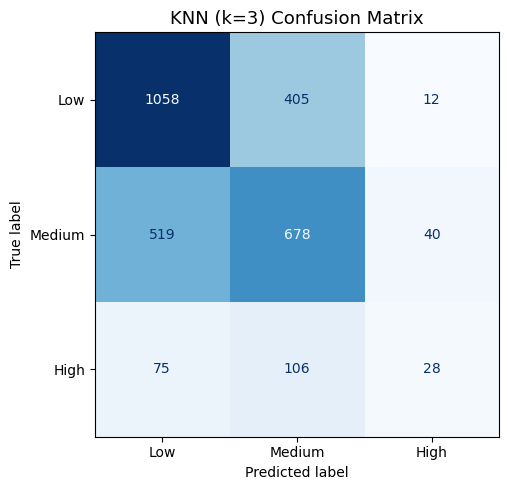

In [13]:
# build a 3*3 confusion matrix

cm = confusion_matrix(y_test, y_pred_km3)

disp = ConfusionMatrixDisplay(confusion_matrix= cm, 
                              display_labels= ['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(6, 5))

# Display Plot

disp.plot(ax = ax, colorbar=False, cmap = 'Blues')
ax.set_ylim(len(['Low', 'Medium', 'High']) - 0.5, -0.5)
ax.set_title('KNN (k=3) Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## Step 4: Manually Calculate Accuracy, Precision, Recall, and F₁

Accuracy alone can be misleading when classes are imbalanced or when certain errors matter more than others. We'll calculate all four metrics **by hand from the confusion matrix** so you can see exactly what each one is measuring.

**Accuracy** is the simplest: the fraction of all predictions that landed on the diagonal:

$$\text{Accuracy} = \frac{\text{sum of diagonal}}{\text{sum of all cells}} = \frac{TP_{Low} + TP_{Med} + TP_{High}}{N}$$

For **precision, recall, and F₁**, each class gets its own TP, FP, and FN read directly from `cm`:

| Term | How to read it from `cm` |
|---|---|
| **TP** for class *i* | `cm[i, i]` — correctly predicted as class *i* |
| **FP** for class *i* | column *i* sum minus `cm[i, i]` — other classes predicted as *i* |
| **FN** for class *i* | row *i* sum minus `cm[i, i]` — class *i* predicted as something else |

$$\text{Precision}_i = \frac{TP_i}{TP_i + FP_i} \qquad \text{Recall}_i = \frac{TP_i}{TP_i + FN_i} \qquad F1_i = \frac{2 \cdot P_i \cdot R_i}{P_i + R_i}$$


### Macro Average

For each class: extract TP, FP, FN from `cm`, compute the three metrics, then take the simple mean across classes.

In [14]:
# ── Accuracy ──────────────────────────────────────────────────────────────────
correct = np.trace(cm)
total = cm.sum()
accuracy_manual = correct / total
print(accuracy_manual)

print(f"Accuracy = {correct} / {total} = {accuracy_manual:.4f}")

# ── Low (class 0) ─────────────────────────────────────────────────────────────
TP_low = cm[0,0]
FP_low = cm[1,0] + cm[2,0] # medium and high values that were predicted as low
FN_low = cm[0,1] + cm[0,2] # low predicted medium or high

precision_low = TP_low / (TP_low + FP_low)
recall_low    = TP_low / (TP_low + FN_low)
f1_low        = (2 * precision_low * recall_low) / (precision_low + recall_low)

print(f"Low    — TP: {TP_low}  FP: {FP_low}  FN: {FN_low}")
print(f"         Precision: {precision_low:.4f}  Recall: {recall_low:.4f}  F1: {f1_low:.4f}")

# ── Medium (class 1) ──────────────────────────────────────────────────────────
TP_med = cm[1,1]
FP_med = cm[0,1] + cm[2,1]
FN_med = cm[1,0] + cm[1,2]

precision_med = TP_med / (TP_med + FP_med)
recall_med    = TP_med / (TP_med + FN_med)
f1_med        = (2 * precision_med * recall_med) / (precision_med + recall_med)

print(f"Medium — TP: {TP_med}  FP: {FP_med}  FN: {FN_med}")
print(f"         Precision: {precision_med:.4f}  Recall: {recall_med:.4f}  F1: {f1_med:.4f}")

# ── High (class 2) ────────────────────────────────────────────────────────────
TP_high = cm[2,2]
FP_high = cm[0,2] + cm[1,2]
FN_high = cm[2,0] + cm[2,1]

precision_high = TP_high / (TP_high + FP_high)
recall_high    = TP_high / (TP_high + FN_high)
f1_high        = (2 * precision_high * recall_high) / (precision_high + recall_high)

print(f"High   — TP: {TP_high}  FP: {FP_high}  FN: {FN_high}")
print(f"         Precision: {precision_high:.4f}  Recall: {recall_high:.4f}  F1: {f1_high:.4f}")

# ── Macro average ─────────────────────────────────────────────────────────────
macro_precision = (precision_low + precision_med + precision_high) / 3
macro_recall    = (recall_low    + recall_med    + recall_high)    / 3
macro_f1        = (f1_low        + f1_med        + f1_high)        / 3

print(f"Macro avg — Precision: {macro_precision:.4f}  Recall: {macro_recall:.4f}  F1: {macro_f1:.4f}")

0.6039027730229374
Accuracy = 1764 / 2921 = 0.6039
Low    — TP: 1058  FP: 594  FN: 417
         Precision: 0.6404  Recall: 0.7173  F1: 0.6767
Medium — TP: 678  FP: 511  FN: 559
         Precision: 0.5702  Recall: 0.5481  F1: 0.5589
High   — TP: 28  FP: 52  FN: 181
         Precision: 0.3500  Recall: 0.1340  F1: 0.1938
Macro avg — Precision: 0.5202  Recall: 0.4665  F1: 0.4765


low recall means wer're not classifying as many highs as high

## Step 5: Verify with Scikit-learn's Built-in Metrics

Now that you've computed everything by hand, use scikit-learn's built-in functions to verify your results.


In [15]:
# ── Accuracy ──────────────────────────────────────────────────────────────────
sk_accuracy = accuracy_score(y_test, y_pred_km3)

# ── Macro-averaged metrics ────────────────────────────────────────────────────
sk_macro_precision = precision_score(y_test, y_pred_km3, average = 'macro')
sk_macro_recall    = recall_score(y_test, y_pred_km3, average= 'macro')
sk_macro_f1        = f1_score(y_test, y_pred_km3, average = 'macro')



In [17]:
print("=== Sklearn Built-in Metrics ===")
print(f"Accuracy          : {sk_accuracy:.4f}")
print()
print(f"Macro Precision   : {sk_macro_precision:.4f}")
print(f"Macro Recall      : {sk_macro_recall:.4f}")
print(f"Macro F1          : {sk_macro_f1:.4f}")

=== Sklearn Built-in Metrics ===
Accuracy          : 0.6039

Macro Precision   : 0.5202
Macro Recall      : 0.4665
Macro F1          : 0.4765
